# **Headpose Estimation with MTCNN**
Author: Aditya Khadkikar

Credit: https://github.com/fisakhan/Face_Pose/blob/master/pose_detection_retinaface.py

Original code from above adapted now to work for the MTCNN runs.

> Because of the files being excessively large in size, outputs are not stored. Run the notebooks to achieve the outputs. You need the necessary libraries in this notebook, and a ZIP folder of all of the images named as `intra-sim.zip`.

In [1]:
# ! pip install deepface --quiet
import cv2, polars as pl, matplotlib.pyplot as plt
import os, pickle, glob, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from deepface import DeepFace
from datasets import load_dataset
import itertools
from mtcnn.mtcnn import MTCNN
from mtcnn.utils.plotting import plot, plot_landmarks
from mtcnn.utils.landmarks import parse_landmarks
from mtcnn.utils.images import load_image

font = cv2.FONT_HERSHEY_SIMPLEX # Text in video
font_size = 0.4
blue = (0, 0, 255)
green = (0,128,0)
red = (255, 0, 0)

detector = MTCNN()

In [ ]:
# !zip -r intra-sim.zip intra-sim
! unzip intra-sim.zip

In [2]:
def detect_faces(image, image_shape_max=None):
    '''
    Performs face detection using retinaface method with speed boost and initial quality checks based on whole image size

    Parameters
    ----------
    image : uint8
        image for face detection.
    image_shape_max : int, optional
        maximum size (in pixels) of image. The default is None.

    Returns
    -------
    float array
        bounding boxes and score.
    float array
        landmarks.

    '''

    image_shape = image.shape[:2]

    # perform image resize for faster detection
    if image_shape_max:
        scale_factor = max([1, max(image_shape) / image_shape_max])
    else:
        scale_factor = 1

    if scale_factor > 1:
        scaled_image = cv2.resize(image, (0, 0), fx = 1/scale_factor, fy = 1/scale_factor)
        bbs, points = detector.detect_faces(scaled_image)
        bbs[:,:4] *= scale_factor
        points *= scale_factor
    else:
        detection = list(detector.detect_faces(image))

    return detection

In [3]:
def find_pose(flattened_points):
    """
    Parameters ---------- points : TYPE - Array of float32, Size = (10,), coordinates of landmarks for the selected faces.
    Returns ------- Angle, Yaw, Pitch

    IMPORTANT NOTE:
    Add the flattened array, and the landmarks order should be sorted for the way it is done in RetinaFace.
          "right_eye": [257.82974, 209.64787],
          "left_eye": [374.93427, 251.78687],
          "nose": [303.4773, 299.91144],
          "mouth_right": [228.37329, 338.73193],
          "mouth_left": [320.21982, 374.58798]
    """
    LMx = flattened_points[:,0] # horizontal coordinates of landmarks
    LMy = flattened_points[:,1] # vertical coordinates of landmarks

    dPx_eyes = max((LMx[1] - LMx[0]), 1)
    dPy_eyes = (LMy[1] - LMy[0])
    angle = np.arctan(dPy_eyes / dPx_eyes) # angle for rotation based on slope eyes

    alpha = np.cos(angle)
    beta = np.sin(angle)
    # rotated landmarks
    LMxr = (alpha * LMx + beta * LMy + (1 - alpha) * LMx[2] / 2 - beta * LMy[2] / 2)
    LMyr = (-beta * LMx + alpha * LMy + beta * LMx[2] / 2 + (1 - alpha) * LMy[2] / 2)

    # average distance between eyes and mouth
    dXtot = (LMxr[1] - LMxr[0] + LMxr[4] - LMxr[3]) / 2
    dYtot = (LMyr[3] - LMyr[0] + LMyr[4] - LMyr[1]) / 2

    # average distance between nose and eyes
    dXnose = (LMxr[1] - LMxr[2] + LMxr[4] - LMxr[2]) / 2
    dYnose = (LMyr[3] - LMyr[2] + LMyr[4] - LMyr[2]) / 2

    # relative rotation 0 degree is frontal 90 degree is profile
    Xfrontal = (-90+90 / 0.5 * dXnose / dXtot) if dXtot != 0 else 0
    Yfrontal = (-90+90 / 0.5 * dYnose / dYtot) if dYtot != 0 else 0

    Xfrontal = 180 if Xfrontal > 180 else Xfrontal
    Xfrontal = -180 if Xfrontal < -180 else Xfrontal
    Yfrontal = 180 if Yfrontal > 180 else Yfrontal
    Yfrontal = -180 if Yfrontal < -180 else Yfrontal

    return (angle * 180 / np.pi), Xfrontal, Yfrontal # 1st: roll, 2nd: yaw, 3rd: pitch

(np.float64(-0.39513704250748827), np.float64(-0.2663284717819039), np.float64(-8.921337144277373))


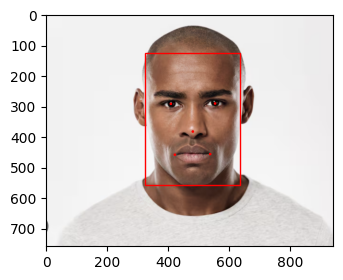

In [115]:
# Tested on a tester image -- coords: (roll, yaw, pitch)

In [ ]:
# Input PNG image path
# image_path = "intra-sim/Alejandro_Toledo_/4.png"

import glob

results = {}
not_recog = []

for p, person in enumerate(glob.glob(f'intra-sim/*')):
  images = glob.glob(f'{person}/*.png')
  for i, image_path in enumerate(images):
    # Read image (PNG) and convert to BGR for OpenCV drawing
    print("-------- Person #", p, "-------- Image #", i+1, "--------")
    try:
        pil = Image.open(image_path).convert("RGB")
        image_rgb = cv2.cvtColor(np.array(pil), cv2.COLOR_RGB2BGR)
        rets = True
    except Exception as e:
        print("Error reading image:", e)
        image_rgb = None
        rets = False
        not_recog += [image_path]

    if not rets or image_rgb is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")

    # Use the loaded image (do not flip by default; uncomment if you want)
    # image_rgb = frame.copy()  # image in BGR order for OpenCV drawing

    try:
      # face detection
      detection = detect_faces(image_rgb) ## this is a tuple.

      # if > 1: take the face with the largest confidence
      # but that is not the used solution. best to manually label.
      if len(detection) > 1:
        print("manually label, multiple faces present here!")
        not_recog += [image_path]

      bounding_boxes = np.array([list(detection[0]['box'])])
      landmarks_unfl = detection[0]['keypoints']
    except Exception as e:
      bounding_boxes, landmarks_unfl = [], []
      print('Possible error:', e, ' --- or no face detected. manually label.')
      cv2.putText(image_rgb, 'no face detected', (10, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 255), 2)
      not_recog += [image_path]

    # if at least one face is detected
    if len(bounding_boxes) > 0:
        ordered = {
          'left_eye': landmarks_unfl['left_eye'],
          'right_eye': landmarks_unfl['right_eye'],
          'nose': landmarks_unfl['nose'],
          'mouth_left': landmarks_unfl['mouth_left'],
          'mouth_right': landmarks_unfl['mouth_right']
        }
        angle, Xfrontal, Yfrontal = find_pose(np.array(list(ordered.values())))
        results[image_path] = {
            "person": person,
            "roll": angle,
            "yaw": Xfrontal,
            "pitch": Yfrontal
        }
        print("roll", angle, " -- yaw", Xfrontal, " -- pitch", Yfrontal)
    else:
        cv2.putText(image_rgb, 'no face detected', (10, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 255), 2)

    # Display inline in Jupyter (convert BGR -> RGB for correct colors)
    try:
      plt.figure(figsize=(5, 3))
      print(detection)
      plt.imshow(cv2.cvtColor(plot(image_rgb, detection), cv2.COLOR_BGR2RGB))
      plt.axis('off')
      plt.show()
    except:
      plt.figure(figsize=(5, 3))
      plt.imshow(cv2.cvtColor(image_rgb, cv2.COLOR_BGR2RGB))
      plt.axis('off')
      plt.show()

In [6]:
len(not_recog)

125

In [8]:
### SAVE PROGRESS AS .pickle
with open('mtcnn-headposes.pickle', 'wb') as file_:
    pickle.dump(results, file_, protocol=pickle.HIGHEST_PROTOCOL)